In [7]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

# Encode labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())


   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label        5572 non-null   int64 
 1   text         5572 non-null   object
 2   text_length  5572 non-null   int64 
 3   num_words    5572 non-null   int64 
 4   num_digits   5572 non-null   int64 
 5   free         5572 non-null   int64 
 6   win          5572 non-null   int64 
 7   offer        5572 non-null   int64 
 8   money        5572 non-null   int64 
 9   urgent       5572 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 435.4+ KB


In [24]:
df.describe()

,label,text_length,num_words,num_digits,free,win,offer,money,urgent
count,5572.000000,5572.000000,5572.000000,5572.000000,5572.000000,5572.000000,5572.000000,5572.000000,5572.000000
mean,0.134063,80.118808,15.494436,2.371859,0.047559,0.029792,0.008256,0.010050,0.012383
std,0.340751,59.690841,11.329427,6.244660,0.212851,0.170028,0.090492,0.099755,0.110599
min,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,36.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,61.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,121.000000,23.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,910.000000,171.000000,47.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
df.isnull().sum()

label          0
text           0
text_length    0
num_words      0
num_digits     0
free           0
win            0
offer          0
money          0
urgent         0
dtype: int64

# 1. Nomial Naive Bayes (For Numerical Data)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

# Feature Engineering: Extract numerical features
df['text_length' ] = df['text'].apply(len)
df['num_words' ] = df['text'].apply(lambda x: len(x.split()))
df['num_digits'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x))

# Define features and target
X = df[['text_length', 'num_words', 'num_digits']]
y = df['label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("Classification Report:\n", classification_report(y_test, y_pred_gnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gnb))


Accuracy: 0.9802690582959641
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.92      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[953  12]
 [ 10 140]]


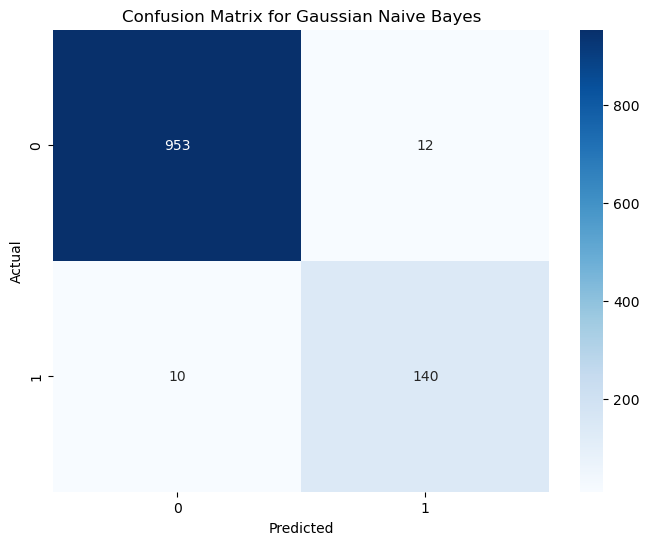

In [ ]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_gnb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.show()

# 2. Multinomial Naive Bayes (For Text Data)

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

# Convert text data into word count vectors
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(df['text'])

# Convert counts to TF-IDF representation
tfidf_transformer = TfidfTransformer() # it will calculate frequency of words
X_tfidf = tfidf_transformer.fit_transform(X_counts)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)

# Train Multinomial Naïve Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

In [16]:
# Evaluation
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("Classification Report:\n", classification_report(y_test, y_pred_mnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mnb))


MultinomialNB Accuracy: 0.968609865470852
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
 [[965   0]
 [ 35 115]]


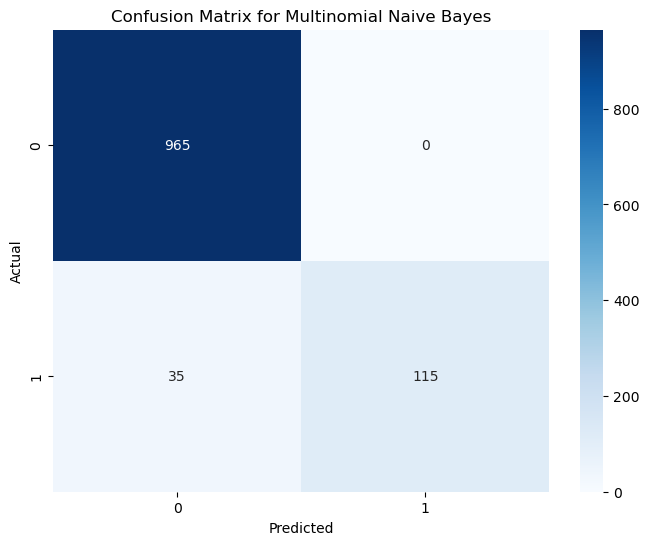

In [18]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_mnb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.show()

# 3. Bernoulli Naive Bayes (For Binary Features)

In [20]:
# Convert text into binary presence/absence of important words
important_words = ["free", "win", "offer", "money", "urgent"]
for word in important_words:
    df[word] = df['text'].apply(lambda x: 1 if word in x.lower() else 0)

# Define features and target
X = df[important_words]
y = df['label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

In [21]:
# Evaluate model
print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred_bnb))
print("Classification Report:\n", classification_report(y_test, y_pred_bnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bnb))

BernoulliNB Accuracy: 0.895067264573991
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       965
           1       0.66      0.46      0.54       150

    accuracy                           0.90      1115
   macro avg       0.79      0.71      0.74      1115
weighted avg       0.88      0.90      0.89      1115

Confusion Matrix:
 [[929  36]
 [ 81  69]]


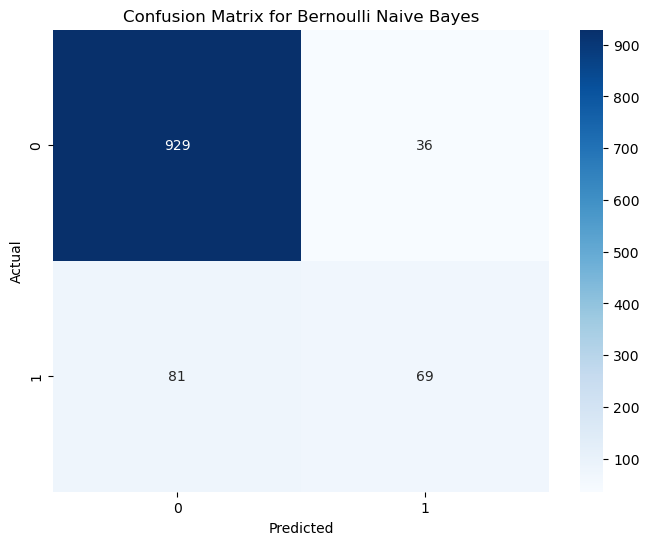

In [ ]:
# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_bnb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Bernoulli Naive Bayes')
plt.show()

1. Load the dataset and explore the message content and labels.
2. Identify how many messages belong to each category.
3. Build a probabilistic classification model that can learn patterns from word occurrences.
4. Train the model using historical message data.
5. Predict whether unseen messages are:
    - Suspicious
    - Not suspicious
6. Test the system using custom user-entered messages.
7. Evaluate the model using appropriate classification metrics.
8. Analyze the following:
    - How many suspicious messages were correctly identified?
    - How many genuine messages were incorrectly flagged?

In [26]:
# 1. Load the dataset and explore the message content and labels.
import pandas as pd
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df.head())


   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [27]:
# 2. Identify how many messages belong to each category.
print(df['label'].value_counts())


label
0    4825
1     747
Name: count, dtype: int64


In [34]:
# 3. Build a probabilistic classification model that can learn patterns from word occurrences.

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Convert text data into word count vectors
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(df['text'])

# Convert counts to TF-IDF representation
tfidf_transformer = TfidfTransformer() # it will calculate frequency of words
X_tfidf = tfidf_transformer.fit_transform(X_counts)

In [35]:
# 4. Train the model using historical message data.

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)


In [36]:
# 5. Predict whether unseen messages are:
   # - Suspicious
   # - Not suspicious

mnb = MultinomialNB()
mnb.fit(X_train, y_train)   
y_pred_mnb = mnb.predict(X_test)

def predict_message(message):
    message_counts = vectorizer.transform([message])
    message_tfidf = tfidf_transformer.transform(message_counts)
    prediction = mnb.predict(message_tfidf)
    return "Suspicious" if prediction[0] == 1 else "Not suspicious"


In [37]:
# 6. Test the system using custom user-entered messages.

user_message = "Congratulations! You've won a free ticket to Bahamas. Call now!"
result = predict_message(user_message)
print(f"The message is classified as: {result}")

The message is classified as: Not suspicious


MultinomialNB Accuracy: 0.968609865470852
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
 [[965   0]
 [ 35 115]]


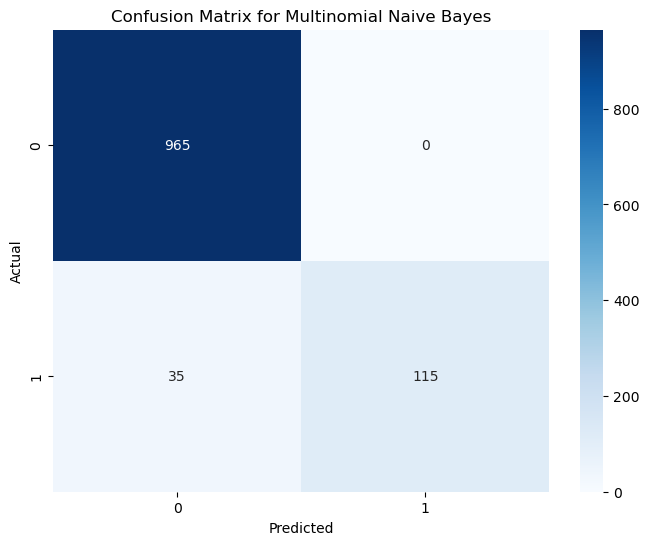

In [39]:
# 7. Evaluate the model using appropriate classification metrics.
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("Classification Report:\n", classification_report(y_test, y_pred_mnb))    
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mnb))



# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_mnb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.show()

True Positives (Correctly identified suspicious messages): 115
False Positives (Non-suspicious messages incorrectly flagged as suspicious): 0
False Negatives (Suspicious messages incorrectly flagged as genuine): 35


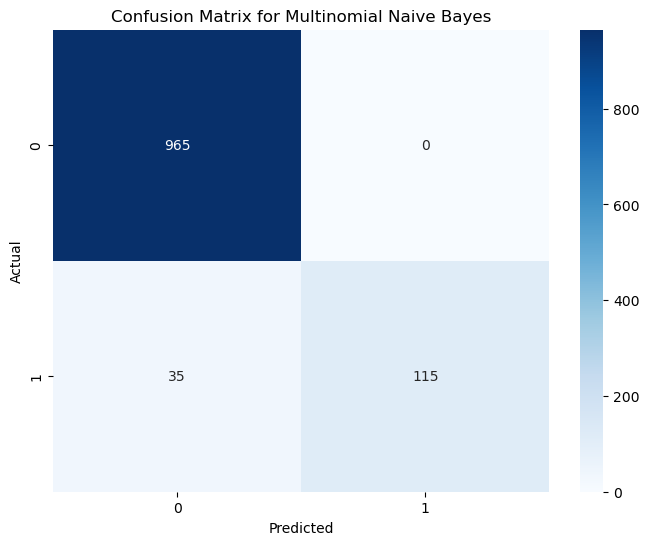

In [ ]:
# 8. Analyze the following:

# - How many suspicious messages were correctly identified?
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_mnb).ravel()
print(f"True Positives (Correctly identified suspicious messages): {tp}")

# - How many non-suspicious messages were incorrectly flagged as suspicious?
print(f"False Positives (Non-suspicious messages incorrectly flagged as suspicious): {fp}")

# - How many genuine messages were incorrectly flagged?
print(f"False Negatives (Suspicious messages incorrectly flagged as genuine): {fn}")